# 03 — Exploration de la couche Gold : Stress Index Géopolitique × WTI

Lecture du fichier `combined/stress_index/` depuis S3 (LocalStack) pour explorer la table produite par `compute_stress_index.py`.

**Colonnes attendues :**
- **WTI** : Datetime, Open, High, Low, Close, Volume, Volatility_Range, Variation_Pct
- **GDELT lissé** : geo_I_smoothed, geo_B_smoothed, geo_S_smoothed, geo_score_raw_smoothed
- **GDELT brut** : geo_I_sum, geo_B_sum, geo_S_sum, geo_score_raw_sum
- **Métadonnées** : total_event_count, gap_duration_15m, period_main_actor
- **Percentile** : score_pct_7d

In [1]:
import io
import os
import boto3
import pandas as pd
import numpy as np

# ── Connexion S3 LocalStack ──
os.environ["AWS_ACCESS_KEY_ID"] = "test"
os.environ["AWS_SECRET_ACCESS_KEY"] = "test"
os.environ["AWS_DEFAULT_REGION"] = "eu-west-1"

s3 = boto3.client("s3", endpoint_url="http://localhost:4566")

# ── Chargement du parquet Gold (dossier Spark) ──
prefix_gold = "combined/stress_index/"
objs_gold = s3.list_objects_v2(Bucket="datalake", Prefix=prefix_gold)
parquet_keys = [o["Key"] for o in objs_gold.get("Contents", []) if o["Key"].endswith(".parquet")]

dfs = []
for key in parquet_keys:
    response = s3.get_object(Bucket="datalake", Key=key)
    dfs.append(pd.read_parquet(io.BytesIO(response["Body"].read()), engine="pyarrow"))

df_gold = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
df_gold = df_gold.sort_values("Datetime").reset_index(drop=True)

print(f"Shape : {df_gold.shape[0]} lignes × {df_gold.shape[1]} colonnes")
print(f"\nColonnes : {list(df_gold.columns)}")
print(f"\nTypes :\n{df_gold.dtypes}")
print(f"\nPlage temporelle : {df_gold['Datetime'].min()} → {df_gold['Datetime'].max()}")
df_gold.head(10)

Shape : 848 lignes × 20 colonnes

Colonnes : ['Datetime', 'Open', 'High', 'Low', 'Close', 'Volume', 'Volatility_Range', 'Variation_Pct', 'geo_I_smoothed', 'geo_B_smoothed', 'geo_S_smoothed', 'geo_score_raw_smoothed', 'geo_I_sum', 'geo_B_sum', 'geo_S_sum', 'geo_score_raw_sum', 'total_event_count', 'gap_duration_15m', 'period_main_actor', 'score_pct_7d']

Types :
Datetime                  datetime64[ns]
Open                             float64
High                             float64
Low                              float64
Close                            float64
Volume                             int64
Volatility_Range                 float64
Variation_Pct                    float64
geo_I_smoothed                   float64
geo_B_smoothed                   float64
geo_S_smoothed                   float64
geo_score_raw_smoothed           float64
geo_I_sum                        float64
geo_B_sum                        float64
geo_S_sum                        float64
geo_score_raw_sum    

,Datetime,Open,High,Low,Close,Volume,Volatility_Range,Variation_Pct,geo_I_smoothed,geo_B_smoothed,geo_S_smoothed,geo_score_raw_smoothed,geo_I_sum,geo_B_sum,geo_S_sum,geo_score_raw_sum,total_event_count,gap_duration_15m,period_main_actor,score_pct_7d
0,2026-02-16 00:00:00,62.900002,62.939999,62.869999,62.930000,126,0.07,NaN,196.4,188.249707,178.083407,2262.403405,982.0,941.248533,890.417035,11312.017025,461.0,5,USA,50.00
1,2026-02-16 00:15:00,62.930000,62.930000,62.869999,62.880001,90,0.06,-0.0795,169.5,148.659147,134.643551,2090.967454,169.5,148.659147,134.643551,2090.967454,73.0,1,USA,0.00
2,2026-02-16 00:30:00,62.880001,62.900002,62.869999,62.880001,38,0.03,0.0000,276.0,241.076314,219.864368,3197.230208,276.0,241.076314,219.864368,3197.230208,121.0,1,USA,100.00
3,2026-02-16 00:45:00,62.880001,62.900002,62.830002,62.860001,144,0.07,-0.0318,195.5,169.031548,152.810359,2605.066757,195.5,169.031548,152.810359,2605.066757,80.0,1,USA,46.47
4,2026-02-16 01:00:00,62.860001,62.930000,62.840000,62.880001,136,0.09,0.0318,167.0,138.223680,142.626162,2154.058042,167.0,138.223680,142.626162,2154.058042,69.0,1,USA,5.70
5,2026-02-16 01:15:00,62.880001,62.910000,62.860001,62.860001,57,0.05,-0.0318,128.0,132.196194,121.555785,1292.121767,128.0,132.196194,121.555785,1292.121767,65.0,1,USA,0.00
6,2026-02-16 01:30:00,62.869999,62.889999,62.840000,62.849998,156,0.05,-0.0159,222.0,173.097464,168.124562,2707.405377,222.0,173.097464,168.124562,2707.405377,90.0,1,USA,74.29
7,2026-02-16 01:45:00,62.860001,62.880001,62.830002,62.869999,173,0.05,0.0318,171.5,179.773369,154.180672,1515.837388,171.5,179.773369,154.180672,1515.837388,92.0,1,USA,11.74
8,2026-02-16 02:00:00,62.860001,62.869999,62.759998,62.790001,384,0.11,-0.1272,226.0,254.701226,222.207263,2372.109615,226.0,254.701226,222.207263,2372.109615,118.0,1,USA,56.69
9,2026-02-16 02:15:00,62.790001,62.849998,62.779999,62.820000,128,0.07,0.0478,188.0,174.295248,158.417592,2272.809946,188.0,174.295248,158.417592,2272.809946,84.0,1,USA,51.48


In [ ]:
print(perio)

In [2]:
# ═══════════════════════════════════════════════
# Statistiques descriptives
# ═══════════════════════════════════════════════
print("Valeurs manquantes :")
print(df_gold.isnull().sum())
print(f"\nDoublons sur Datetime : {df_gold.duplicated(subset=['Datetime']).sum()}")
print(f"\nStatistiques numériques :")
df_gold.describe().round(4)

Valeurs manquantes :
Datetime                  0
Open                      0
High                      0
Low                       0
Close                     0
Volume                    0
Volatility_Range          0
Variation_Pct             1
geo_I_smoothed            0
geo_B_smoothed            0
geo_S_smoothed            0
geo_score_raw_smoothed    0
geo_I_sum                 0
geo_B_sum                 0
geo_S_sum                 0
geo_score_raw_sum         0
total_event_count         0
gap_duration_15m          0
period_main_actor         0
score_pct_7d              0
dtype: int64

Doublons sur Datetime : 0

Statistiques numériques :


,Datetime,Open,High,Low,Close,Volume,Volatility_Range,Variation_Pct,geo_I_smoothed,geo_B_smoothed,geo_S_smoothed,geo_score_raw_smoothed,geo_I_sum,geo_B_sum,geo_S_sum,geo_score_raw_sum,total_event_count,gap_duration_15m,score_pct_7d
count,848,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000,847.0000,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000
mean,2026-02-22 18:13:26.603773440,65.5486,65.6488,65.4431,65.5524,3853.6828,0.2056,0.0154,325.7004,298.6784,275.3044,3689.1976,490.8384,441.6032,412.2401,5778.7363,218.5130,1.6132,41.0669
min,2026-02-16 00:00:00,61.8600,61.9900,61.7600,61.8600,38.0000,0.0300,-2.0011,74.0000,89.3636,83.4033,706.2016,74.0000,89.3636,83.4033,706.2016,43.0000,1.0000,0.0000
25%,2026-02-19 06:56:15,65.0700,65.1675,64.9900,65.0800,676.7500,0.1100,-0.0851,255.5000,245.4458,226.8406,2742.9881,255.5000,246.0488,227.4645,2757.3406,123.0000,1.0000,28.0225
50%,2026-02-23 13:52:30,65.8900,65.9800,65.7900,65.9000,1932.5000,0.1600,0.0151,320.7500,297.4196,273.9475,3564.1772,322.5000,297.8979,274.7510,3567.0191,148.0000,1.0000,39.1300
75%,2026-02-25 20:48:45,66.4000,66.5100,66.2900,66.4100,5351.2500,0.2500,0.1077,385.3750,343.8472,316.6425,4494.3655,388.0000,346.0881,319.6182,4507.1303,172.0000,1.0000,51.5350
max,2026-03-02 04:45:00,72.5400,73.0000,72.2700,72.5300,46560.0000,1.7600,7.7872,683.0000,565.6581,527.1459,8414.2605,64224.0000,51732.8431,51683.1908,891312.8779,25438.0000,197.0000,100.0000
std,NaN,1.6690,1.6928,1.6378,1.6665,4893.0631,0.1689,0.3523,96.1717,76.5714,72.0443,1286.8453,2694.8288,2287.0280,2224.4613,35376.5611,1126.9679,10.0681,18.1465


---
## Visualisations

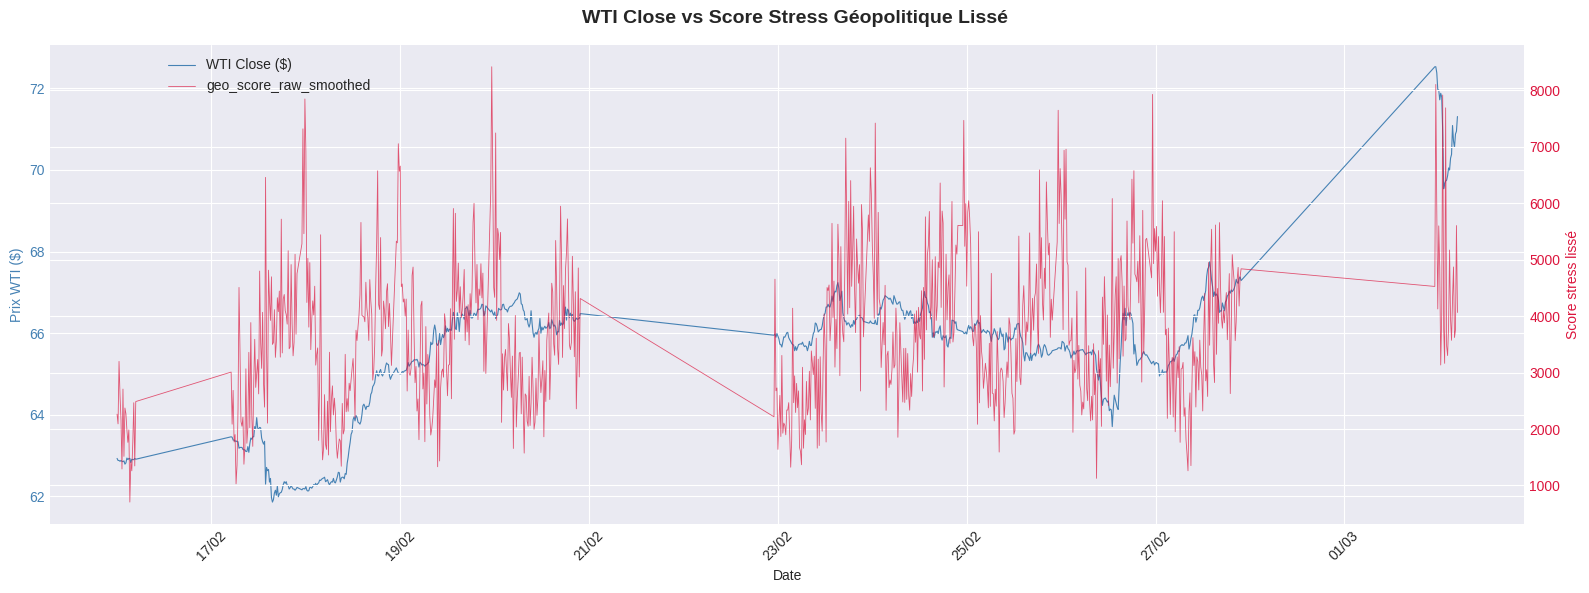

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-v0_8-darkgrid")

# ═══════════════════════════════════════════════
# 1. Prix WTI (Close) + Score Stress lissé (double axe)
# ═══════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.plot(df_gold["Datetime"], df_gold["Close"], color="steelblue", linewidth=0.8, label="WTI Close ($)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Prix WTI ($)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(df_gold["Datetime"], df_gold["geo_score_raw_smoothed"], color="crimson", linewidth=0.6, alpha=0.7, label="geo_score_raw_smoothed")
ax2.set_ylabel("Score stress lissé", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")

fig.suptitle("WTI Close vs Score Stress Géopolitique Lissé", fontweight="bold", fontsize=14)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.92))
plt.tight_layout()
plt.show()

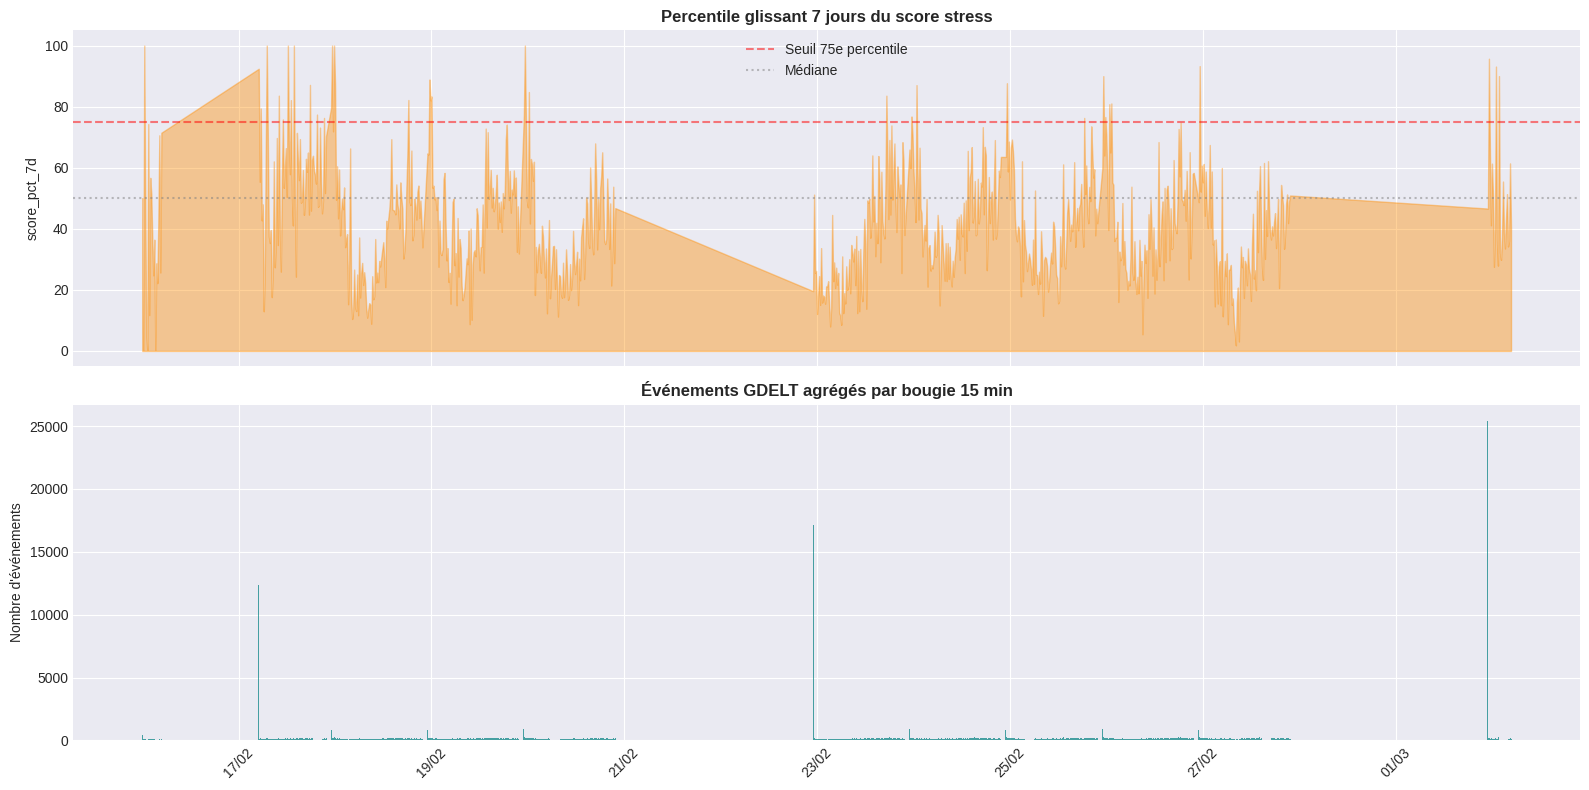

In [4]:
# ═══════════════════════════════════════════════
# 2. Percentile 7 jours (score_pct_7d) + Nombre d'événements
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Percentile 7j
axes[0].fill_between(df_gold["Datetime"], df_gold["score_pct_7d"], alpha=0.4, color="darkorange")
axes[0].axhline(y=75, color="red", linestyle="--", alpha=0.5, label="Seuil 75e percentile")
axes[0].axhline(y=50, color="gray", linestyle=":", alpha=0.5, label="Médiane")
axes[0].set_ylabel("score_pct_7d")
axes[0].set_title("Percentile glissant 7 jours du score stress", fontweight="bold")
axes[0].legend()

# Nombre d'événements
axes[1].bar(df_gold["Datetime"], df_gold["total_event_count"], color="teal", alpha=0.7, width=0.01)
axes[1].set_ylabel("Nombre d'événements")
axes[1].set_title("Événements GDELT agrégés par bougie 15 min", fontweight="bold")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

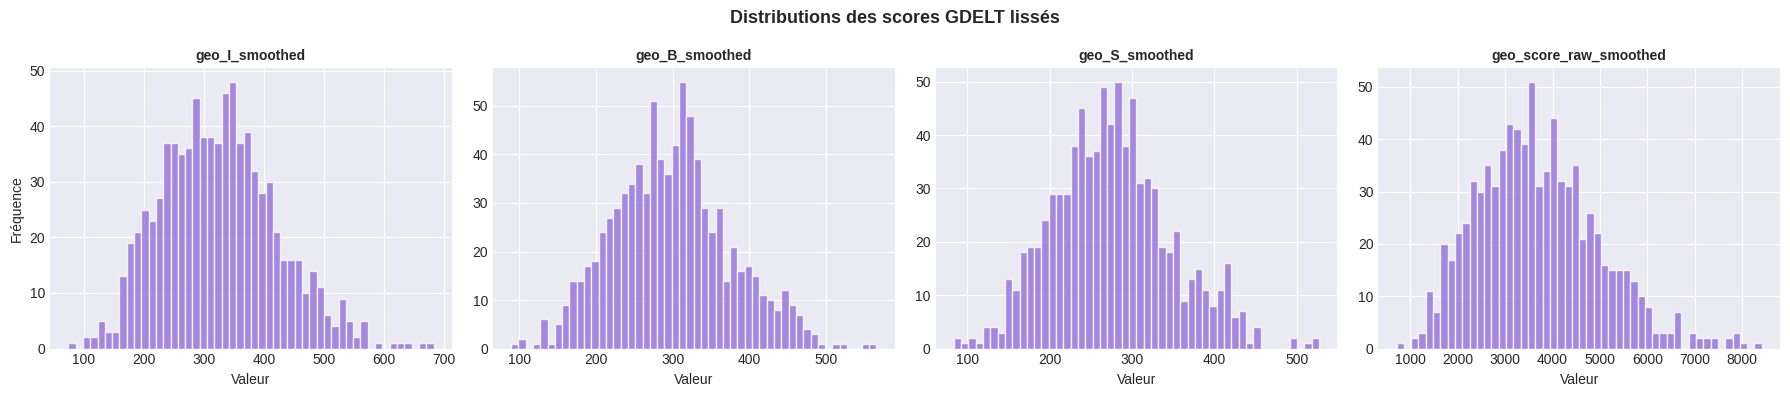

In [5]:
# ═══════════════════════════════════════════════
# 3. Distributions des scores lissés
# ═══════════════════════════════════════════════
score_cols_smoothed = ["geo_I_smoothed", "geo_B_smoothed", "geo_S_smoothed", "geo_score_raw_smoothed"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(score_cols_smoothed):
    axes[i].hist(df_gold[col].dropna(), bins=50, color="mediumpurple", alpha=0.8, edgecolor="white")
    axes[i].set_title(col, fontweight="bold", fontsize=10)
    axes[i].set_xlabel("Valeur")
    axes[i].set_ylabel("Fréquence" if i == 0 else "")

plt.suptitle("Distributions des scores GDELT lissés", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

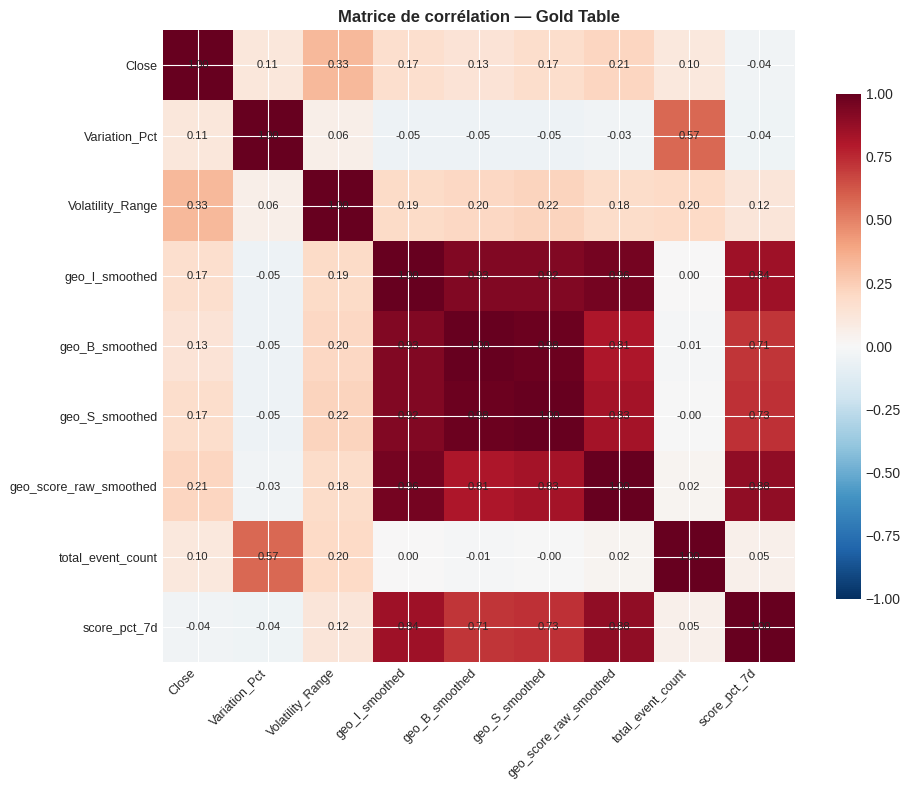

In [6]:
# ═══════════════════════════════════════════════
# 4. Matrice de corrélation
# ═══════════════════════════════════════════════
corr_cols = [
    "Close", "Variation_Pct", "Volatility_Range",
    "geo_I_smoothed", "geo_B_smoothed", "geo_S_smoothed", "geo_score_raw_smoothed",
    "total_event_count", "score_pct_7d",
]
corr_matrix = df_gold[corr_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

# Annotations
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.title("Matrice de corrélation — Gold Table", fontweight="bold")
plt.tight_layout()
plt.show()

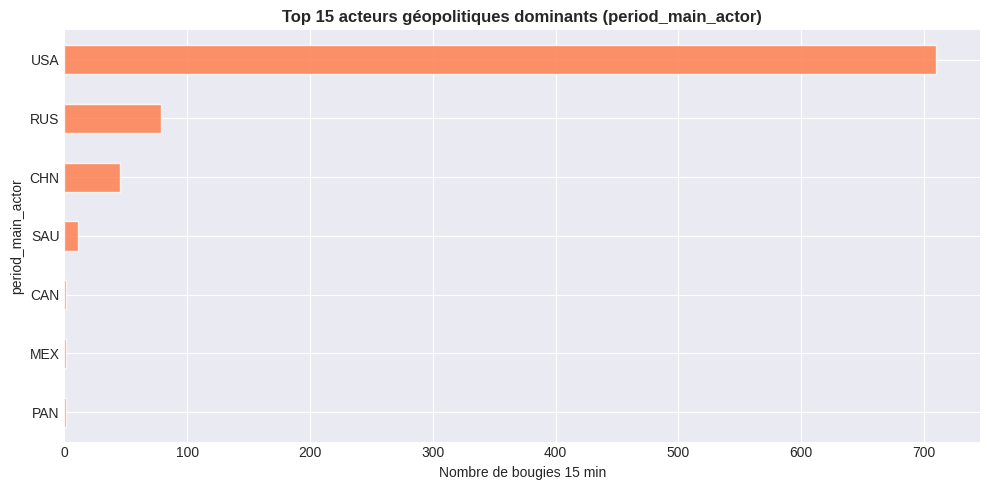

In [7]:
# ═══════════════════════════════════════════════
# 5. Top acteurs géopolitiques (period_main_actor)
# ═══════════════════════════════════════════════
top_actors = df_gold["period_main_actor"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_actors.plot(kind="barh", color="coral", alpha=0.85, edgecolor="white", ax=ax)
ax.set_title("Top 15 acteurs géopolitiques dominants (period_main_actor)", fontweight="bold")
ax.set_xlabel("Nombre de bougies 15 min")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

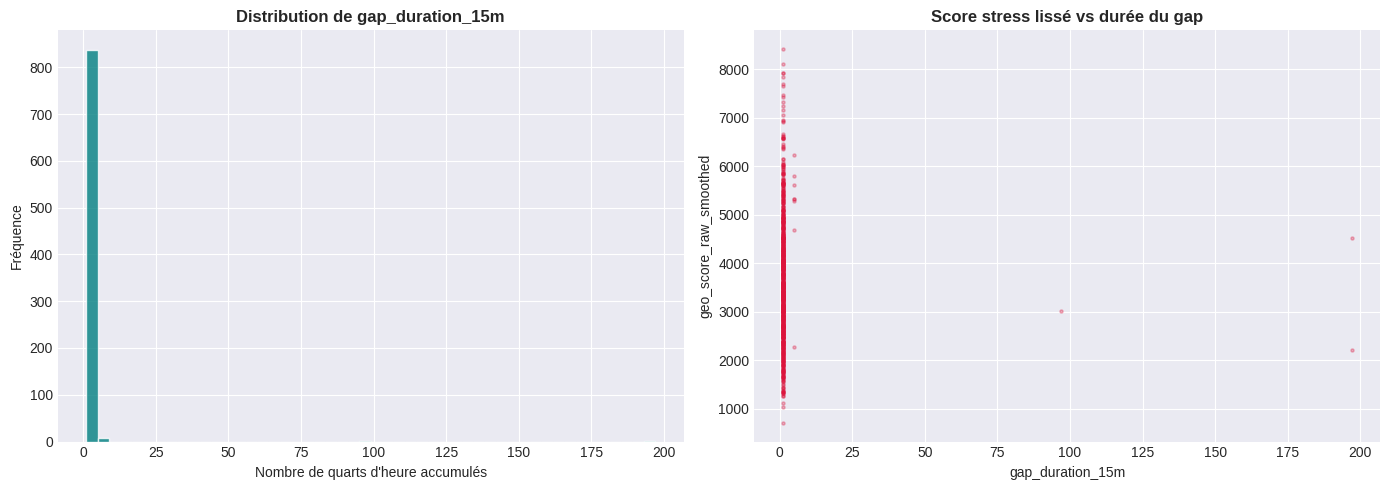

In [8]:
# ═══════════════════════════════════════════════
# 6. Gap duration : analyse du forward mapping
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de gap_duration_15m
axes[0].hist(df_gold["gap_duration_15m"].dropna(), bins=50, color="teal", alpha=0.8, edgecolor="white")
axes[0].set_title("Distribution de gap_duration_15m", fontweight="bold")
axes[0].set_xlabel("Nombre de quarts d'heure accumulés")
axes[0].set_ylabel("Fréquence")

# Score stress vs gap_duration (les réouvertures après longs gaps sont-elles plus stressées ?)
axes[1].scatter(df_gold["gap_duration_15m"], df_gold["geo_score_raw_smoothed"],
               alpha=0.3, s=5, color="crimson")
axes[1].set_title("Score stress lissé vs durée du gap", fontweight="bold")
axes[1].set_xlabel("gap_duration_15m")
axes[1].set_ylabel("geo_score_raw_smoothed")

plt.tight_layout()
plt.show()

In [9]:
# ═══════════════════════════════════════════════
# 7. Aperçu des lignes avec le score stress le plus élevé
# ═══════════════════════════════════════════════
top_stress = df_gold.nlargest(20, "geo_score_raw_smoothed")[
    ["Datetime", "Close", "Variation_Pct", "geo_score_raw_smoothed",
     "score_pct_7d", "total_event_count", "period_main_actor", "gap_duration_15m"]
]
print("Top 20 bougies avec le score stress lissé le plus élevé :")
top_stress

Top 20 bougies avec le score stress lissé le plus élevé :


,Datetime,Close,Variation_Pct,geo_score_raw_smoothed,score_pct_7d,total_event_count,period_main_actor,gap_duration_15m
273,2026-02-19 23:15:00,66.570000,0.0752,8414.260536,100.00,244.0,USA,1
825,2026-03-01 23:15:00,72.529999,0.0000,8101.207385,95.70,205.0,USA,1
733,2026-02-26 23:15:00,65.290001,0.0613,7925.086565,93.29,283.0,USA,1
832,2026-03-02 01:00:00,70.959999,-1.1562,7913.536381,93.13,202.0,USA,1
91,2026-02-17 23:45:00,62.180000,-0.0161,7843.881141,100.00,239.0,USA,1
835,2026-03-02 01:45:00,69.730003,0.0861,7686.845782,90.02,232.0,USA,1
641,2026-02-25 23:15:00,65.639999,0.0457,7643.760799,90.00,257.0,CHN,1
549,2026-02-24 23:15:00,66.000000,-0.0606,7464.720308,87.68,234.0,USA,1
463,2026-02-24 00:45:00,66.320000,0.1359,7416.774442,87.06,207.0,USA,1
89,2026-02-17 23:15:00,62.189999,0.0483,7314.848148,100.00,225.0,USA,1
